# Decision models in repeated economic games

GPT-6 Luna (OpenAI Decisions API) and Jev 1.13.0 (TypeSafe), using Simon Willison's
`llm-openai-decisions` and `llm-typesafe` plugins. Data collected 6 October 2026 Pacific.

The primary comparison uses the APIs' selected actions. Sampling from their
distributions is a **separate experimenter-imposed policy**, not a claim that
classification probabilities are strategic mixing probabilities. Each agent
maximizes its own total payoff in a known twenty-round match with public history.

The panel contains 48 direct-choice head-to-head matches, 24 sampled head-to-head
matches, and 12 self-play matches. Seats are swapped within seeds; option order
varies by seat and round. All 1,680 rounds are replayed below from saved calls.
This notebook makes no network requests. Run from the complete repository or
downloaded replication bundle, not the notebook file alone.

[API documentation](https://developers.openai.com/api/docs/guides/decisions) ·
[Jev documentation](https://docs.typesafe.ai/api) ·
[Plugin announcement](https://simonwillison.net/2026/Oct/6/llm-openai-decisions/)

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, Image
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'lludens/sysone').exists())
experiment = root/'experiments/decisions_jev_games_2026_10_06'
sys.path.insert(0, str(root)); sys.path.insert(0, str(experiment))
from analyze import audit_and_load, summarize, TITLES
rounds, matches, replay, journal = audit_and_load()
summary, probes = summarize(rounds, matches, journal)
json.loads((experiment/'data/audit.json').read_text())

{'matches_replayed': 84,
 'rounds_replayed': 1680,
 'exact_saved_requests': 3360,
 'payoffs_and_actions_match': True,
 'network_calls_during_audit': 0}

## Opening prompts and payloads

The following are the actual first-round decisions in the first unswapped
Prisoner's Dilemma match. `llm_kwargs` holds the exact arguments supplied to LLM,
including the role-adjusted state prompt, question instructions and option order.
`api_payload` is reconstructed offline by the pinned plugin; it is not a captured
HTTP transaction. `answer` is the unchanged typed payload retained from
`response.text()`. Neither model receives the other's current move.

In [2]:
from opening_examples import opening_examples
examples = opening_examples(journal)
for example in examples:
    print(example['model_id'], '->', example['returned_model'])
    print(json.dumps({k: example[k] for k in ('llm_kwargs', 'api_payload', 'answer')}, indent=2))

openai-decisions/gpt-6-luna -> gpt-6-luna
{
  "llm_kwargs": {
    "prompt": "Repeated Prisoner's Dilemma. Both choose C or D simultaneously. Payoffs (your action, other action -> your points, other points): C,C -> 3,3; C,D -> 0,5; D,C -> 5,0; D,D -> 1,1.\nYou are player 1 in a two-player match. This is round 1 of exactly 20. Both players know the rules and the fixed horizon, and face the same opponent throughout. Both choose without seeing the other's current move. After each round both actions and payoffs are revealed. There is no communication. You do not know the opponent's strategy or identity. No side payments, other rewards, or later matches affect your score. Your objective is your own total points, not beating the other's score or maximizing the joint score.\nYour points so far: 0.\nComplete public history from your perspective: []",
    "system": "Choose your action for the current round to maximize YOUR OWN expected total points over the entire match, including future rounds.

## Economic primitives

- Prisoner's Dilemma: CC=(3,3), CD=(0,5), DC=(5,0), DD=(1,1).
- Stag Hunt: SS=(4,4), SH=(0,3), HS=(3,0), HH=(3,3).
- Two-player public goods: fresh endowment 10; contributions {0,2,4,6,8,10};
  pool multiplier 1.6 and equal sharing. Payoff $10-c_i+0.8(c_i+c_j)$.

Defection and zero contribution are one-shot best responses in the first and
third games. Stag Hunt has two pure equilibria; Stag is optimal against a belief
of more than 0.75 on the other choosing Stag. A fixed finite horizon provides no
standard complete-information backward-induction support for cooperation in PD
or public goods. Low cooperation is not, on its own, a model error.

## Head-to-head behavior and payoffs

Means are computed across matches, not across independent rounds. Bootstrap
intervals resample entire seat-swapped seed pairs (eight for the primary panel,
four for sampling). They are small-sample, design-conditional pilot summaries.

,game,policy,matches,luna_points,jev_points,decisions_contribution,jev_contribution,luna_minus_jev,paired_bootstrap_low,paired_bootstrap_high
0,prisoners_dilemma,argmax,16,0.9625,1.1969,0.0500,0.0031,-0.2344,-0.3281,-0.1406
1,prisoners_dilemma,sample,8,1.3062,1.2438,0.0875,0.1000,0.0625,-0.1562,0.2188
2,public_goods,argmax,16,9.9788,10.0850,0.0106,0.0000,-0.1063,-0.1438,-0.0625
3,public_goods,sample,8,10.8425,10.1925,0.0538,0.1188,0.6500,0.3125,1.1625
4,stag_hunt,argmax,16,2.8781,3.0000,0.0406,0.0000,-0.1219,-0.1406,-0.0937
5,stag_hunt,sample,8,2.7312,2.7688,0.1312,0.1188,-0.0375,-0.0750,0.0375


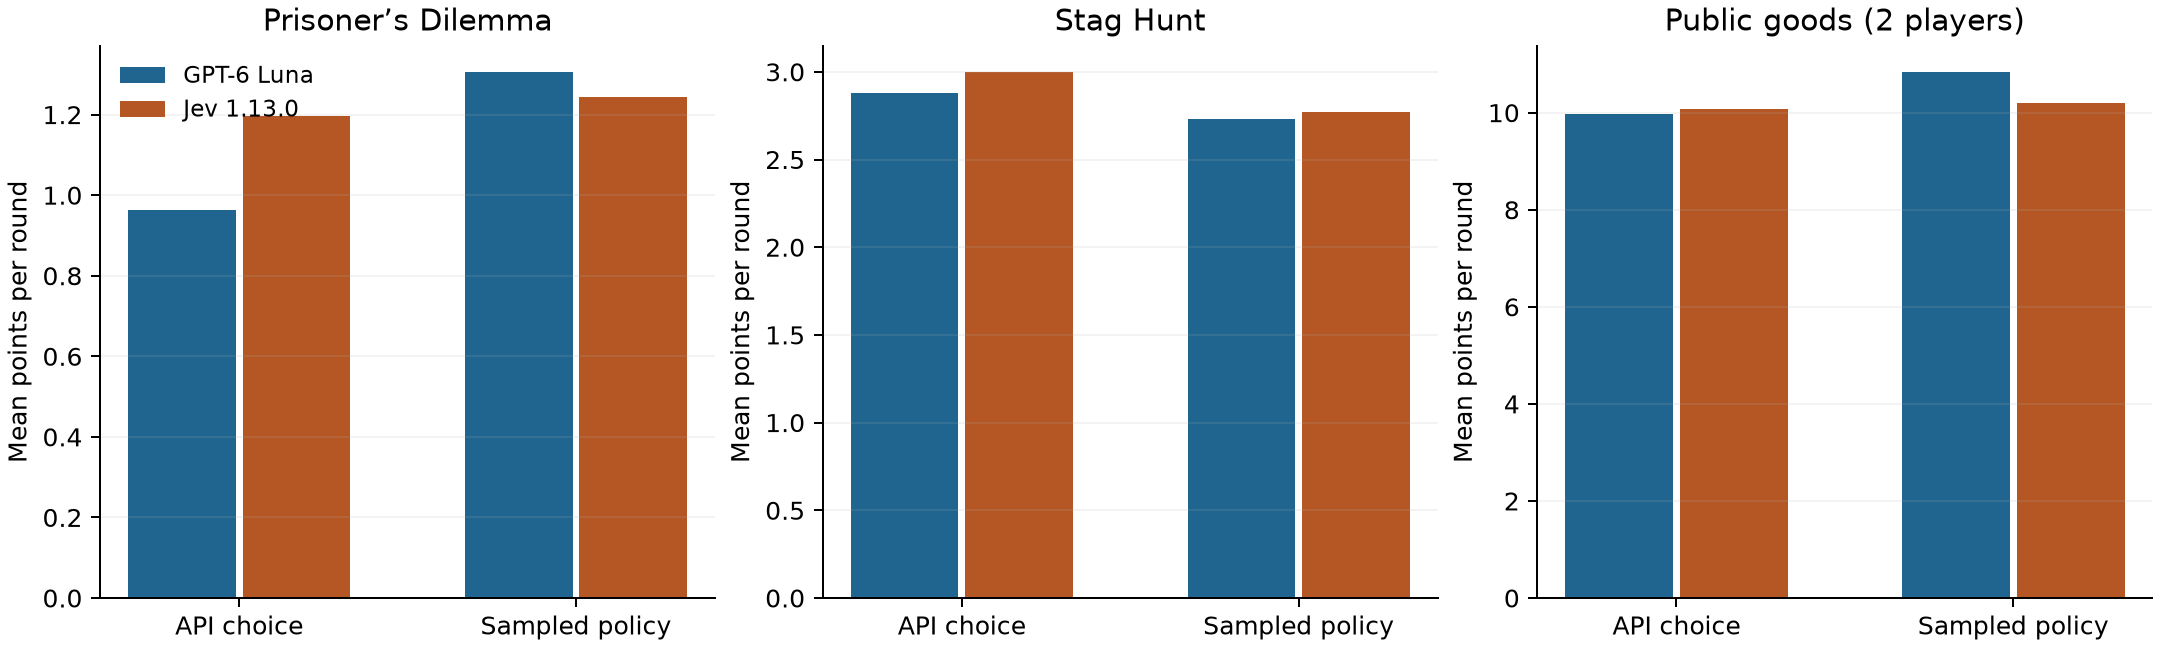

In [3]:
head = pd.DataFrame(summary['h2h'])
display(head[['game','policy','matches','luna_points','jev_points',
              'decisions_contribution','jev_contribution','luna_minus_jev',
              'paired_bootstrap_low','paired_bootstrap_high']].round(4))
display(Image(filename=str(experiment/'report/payoffs.png')))

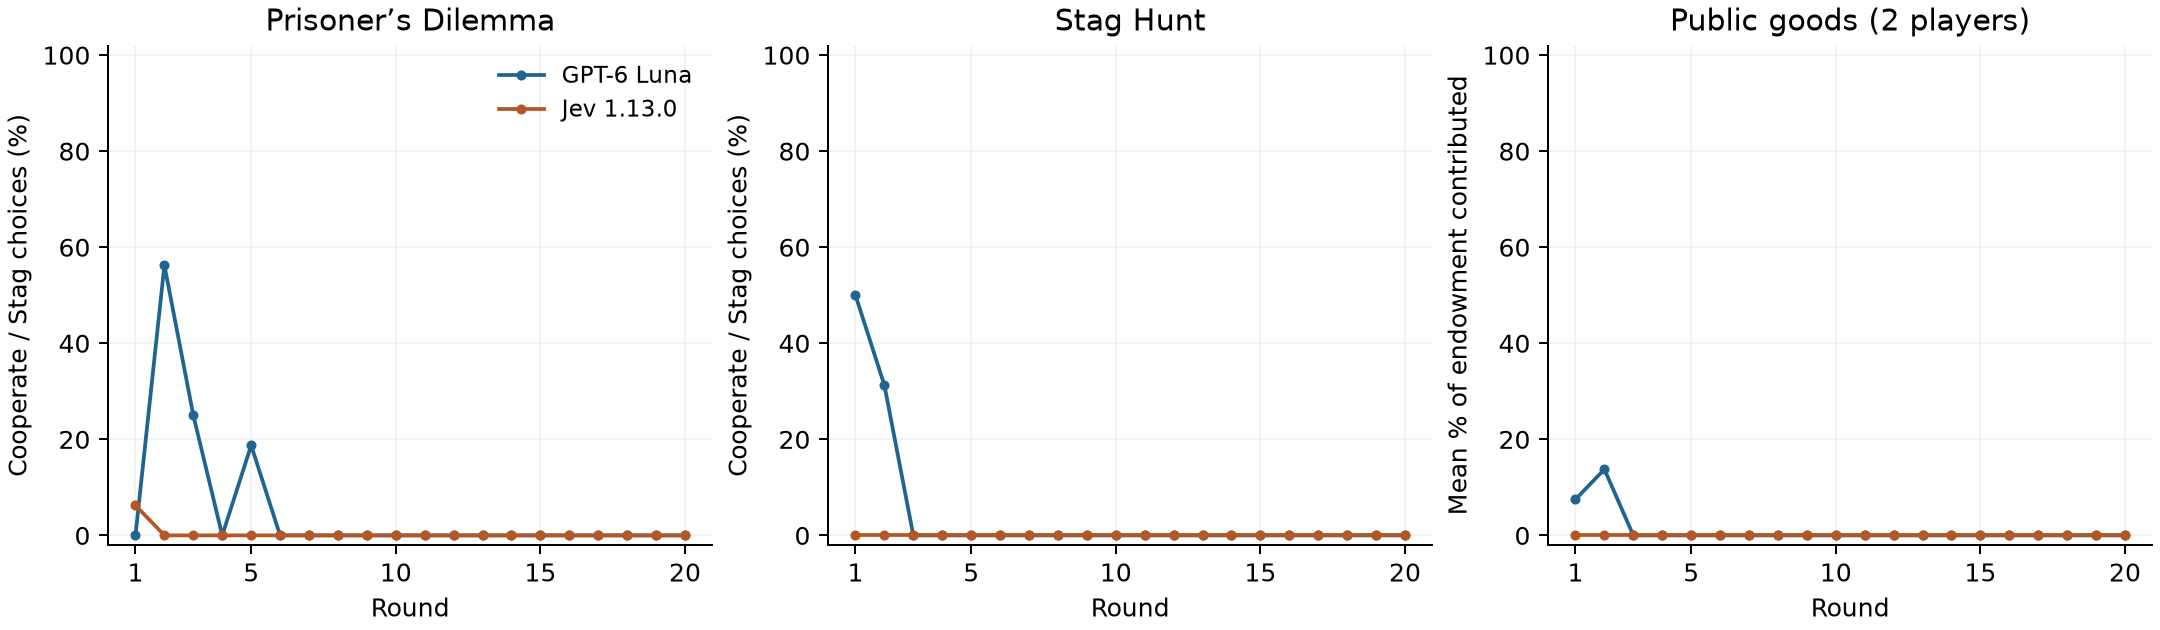

,game,policy,luna_wins,ties,jev_wins,joint_optimum_fraction
0,prisoners_dilemma,argmax,1,2,13,0.3599
1,prisoners_dilemma,sample,4,2,2,0.4250
2,public_goods,argmax,0,5,11,0.6270
3,public_goods,sample,7,0,1,0.6573
4,stag_hunt,argmax,0,3,13,0.7348
5,stag_hunt,sample,2,3,3,0.6875


In [4]:
display(Image(filename=str(experiment/'report/cooperation.png')))
display(head[['game','policy','luna_wins','ties','jev_wins','joint_optimum_fraction']].round(4))

Jev's selected actions earn slightly more in all three primary panels, while
Luna occasionally attempts cooperation or Stag. Sampling changes the interaction
and reverses the PD and public-goods mean ranking. This is not evidence for a
general model leaderboard, and a payoff advantage need not increase group welfare.

## Known-opponent incentives and controlled histories

Each model sees every fixed opposing action in a one-round setting, under both
option orders. Separately, 21 fixed histories are queried forward, reversed, and
identically repeated. The histories were specified before inspecting probe results.

In [5]:
display(pd.DataFrame(summary['probes']).T)
rows = [{'game':p['game'],'history':p['case'],'model':p['provider'],
         'variant':p['variant'],'choice':p['result']['choice']}
        for p in probes if p['kind']=='history']
display(pd.DataFrame(rows).pivot(index=['game','history','model'],columns='variant',values='choice'))

,best_response_correct,best_response_total,states,order_flips,repeat_flips
decisions,20,20,21,1,0
jev,20,20,21,0,1


variant                                                   forward repeat  \
game              history                       model                      
prisoners_dilemma alternating                   decisions       C      C   
                                                jev             C      C   
                  empty                         decisions       D      D   
                                                jev             D      D   
                  final_round_after_cooperation decisions       D      D   
                                                jev             D      D   
                  mutual_cooperation            decisions       C      C   
                                                jev             C      C   
                  mutual_safe_or_selfish        decisions       D      D   
                                                jev             D      D   
                  other_exploited               decisions       D      D   
                                                jev             D      D   
                  you_exploited                 decisions       D      D   
                                                jev             D      D   
public_goods      alternating                   decisions       0      0   
                                                jev             0      0   
                  empty                         decisions       0      0   
                                                jev             0      0   
                  final_round_after_cooperation decisions       0      0   
                                                jev             0      0   
                  mutual_cooperation            decisions      10     10   
                                                jev             0     10   
                  mutual_safe_or_selfish        decisions       0      0   
                                                jev             0      0   
                  other_exploited               decisions       0      0   
                                                jev             0      0   
                  you_exploited                 decisions       0      0   
                                                jev             0      0   
stag_hunt         alternating                   decisions    Stag   Stag   
                                                jev          Stag   Stag   
                  empty                         decisions    Stag   Stag   
                                                jev          Hare   Hare   
                  final_round_after_cooperation decisions    Stag   Stag   
                                                jev          Stag   Stag   
                  mutual_cooperation            decisions    Stag   Stag   
                                                jev          Stag   Stag   
                  mutual_safe_or_selfish        decisions    Hare   Hare   
                                                jev          Hare   Hare   
                  other_exploited               decisions    Hare   Hare   
                                                jev          Hare   Hare   
                  you_exploited                 decisions    Hare   Hare   
                                                jev          Hare   Hare   

variant                                                   reverse  
game              history                       model              
prisoners_dilemma alternating                   decisions       C  
                                                jev             C  
                  empty                         decisions       D  
                                                jev             D  
                  final_round_after_cooperation decisions       D  
                                                jev             D  
                  mutual_cooperation            decisions       C  
                                           

Both models get 20/20 known-opponent best responses right. They condition
on supplied history: PD cooperation follows sustained cooperation, but not
sustained defection, and both defect in the final round after cooperation.
Luna's opening Stag Hunt choice flips when option order is reversed. Jev's
public-goods choice following sustained contribution changes on an identical
repeat. Neither diagnostic establishes universal order robustness or determinism.

In [6]:
display(pd.DataFrame(summary['self_play']).round(4))
display(pd.DataFrame(summary['usage']).T)

,game,provider,mean_points,mean_contribution
0,prisoners_dilemma,decisions,1.075,0.0250
1,prisoners_dilemma,jev,1.000,0.0000
2,public_goods,decisions,10.135,0.0225
3,public_goods,jev,10.000,0.0000
4,stag_hunt,decisions,3.425,0.5250
5,stag_hunt,jev,3.000,0.0000


,retained_calls,input_tokens,estimated_usd,median_latency_ms,p90_latency_ms,quantized_mass_adjustments,models
decisions,1763,1155420,0.115542,464.186667,978.582175,0,[gpt-6-luna]
jev,1763,1553942,0.065266,213.4905,563.650641,3,[jev-1.13.0]


## Interpretation and replication limits

One Luna self-play Stag Hunt match coordinates on Stag for all twenty rounds;
the other does not. Jev self-play chooses Hare throughout both matches. Two
self-play matches per model/game are not enough to estimate equilibrium-selection
probabilities.

All 3,526 retained game and diagnostic responses are available in the journals,
including prompts, option ordering, returned answers, model IDs, usage, and timing.
Latency includes network/connection setup under concurrent load. The estimated
~18-cent total excludes setup calls and initially rejected validation responses.

Jev probabilities are rounded to two decimals. Raw values are retained and small
mass errors consistent with rounding are normalized for sampling. Twelve initial
validation rejections were not retained and were reissued; earlier successful
moves and histories were preserved. No failed call became a default action.

The complete report adds an interactive replay of every match. See the experiment
README for pinned package commits, live-run instructions, and execution provenance.
The scope is one prompt framing, one finite horizon, one payoff matrix per game,
no communication, and a two-player rather than larger-group public-goods game.